   시간대 시간구간
0   13   오후
1   13   오후
2   14   오후
3   14   오후
4   16   오후
시간구간
새벽     14
야간    400
오전    194
오후    489
Name: 승차건수, dtype: int64
시간구간
새벽     11
야간    411
오전    179
오후    465
Name: 하차건수, dtype: int64


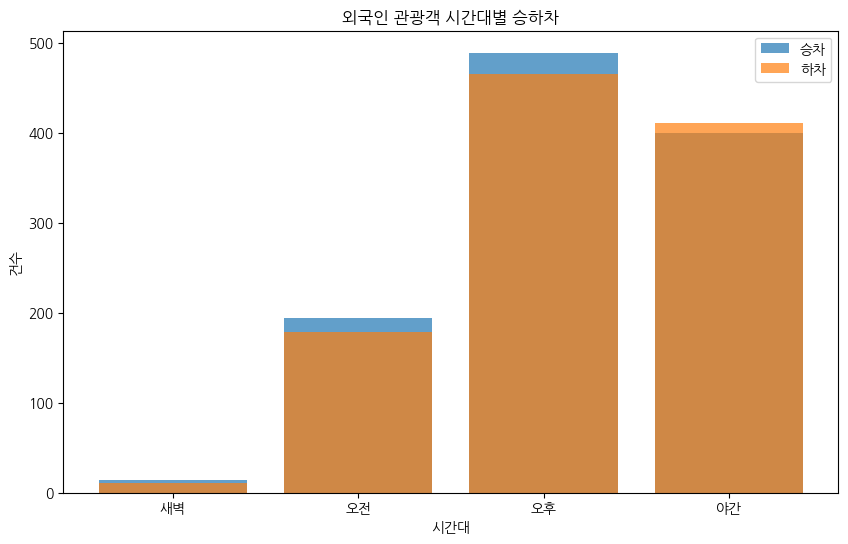

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "NanumGothic"

# csv 불러오기
df = pd.read_csv(r'C:\Users\USER\OneDrive\바탕 화면\시각화 공모전 데이터\서울교통공사_외국인 관광객 기간권 일별통행통계.csv', encoding='cp949')

# 시간대 그룹화 함수
def time_group(hour):
    if 0 <= hour <= 5:
        return '새벽'
    elif 6 <= hour <= 11:
        return '오전'
    elif 12 <= hour <= 17:
        return '오후'
    else:
        return '야간'

# 시간구간 컬럼 생성
df['시간구간'] = df['시간대'].apply(time_group)

print(df[['시간대', '시간구간']].head())

#승차
boarding = df.groupby('시간구간')['승차건수'].sum()
print(boarding)

#하차
alighting = df.groupby('시간구간')['하차건수'].sum()
print(alighting)

import matplotlib.pyplot as plt

# 시간 순서 고정
order = ['새벽', '오전', '오후', '야간']

boarding = boarding.reindex(order)
alighting = alighting.reindex(order)

plt.figure(figsize=(10,6))

plt.bar(order, boarding, alpha=0.7, label='승차')
plt.bar(order, alighting, alpha=0.7, label='하차')

plt.title('외국인 관광객 시간대별 승하차')
plt.xlabel('시간대')
plt.ylabel('건수')
plt.legend()

plt.show()



     역명 시간구간  승차건수
0    강남   야간     5
1    강남   오전     3
2    강남   오후    16
3  강남구청   오전     0
4  강남구청   오후     0
시간구간          새벽   오전    오후   야간
역명                              
강남           0.0  3.0  16.0  5.0
강남구청         0.0  0.0   0.0  0.0
강변(동서울터미널)   0.0  0.0   1.0  0.0
건대입구         0.0  0.0   1.0  4.0
경복궁(정부서울청사)  0.0  0.0  25.0  4.0


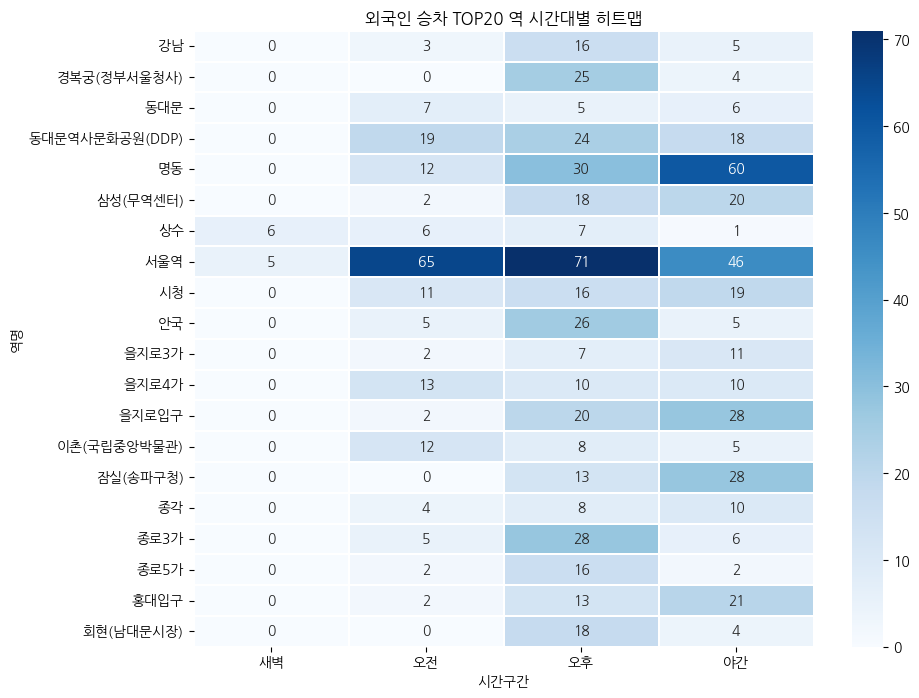

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 불러오기
df = pd.read_csv('C:\\Users\\USER\\OneDrive\\바탕 화면\\시각화 공모전 데이터\\서울교통공사_외국인 관광객 기간권 일별통행통계.csv', encoding='cp949')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'

# 시간대 그룹 함수
def time_group(hour):
    if 0 <= hour <= 5:
        return '새벽'
    elif 6 <= hour <= 11:
        return '오전'
    elif 12 <= hour <= 17:
        return '오후'
    else:
        return '야간'

# 시간구간 컬럼 생성
df['시간구간'] = df['시간대'].apply(time_group)

# =========================
# 역별 시간대별 승차건수 집계
# =========================

station_time_boarding = df.groupby(
    ['역명', '시간구간']
)['승차건수'].sum().reset_index()

print(station_time_boarding.head())

# =========================
# Pivot Table 생성
# =========================

pivot_boarding = station_time_boarding.pivot(
    index='역명',
    columns='시간구간',
    values='승차건수'
).fillna(0)

# 시간 순서 고정
pivot_boarding = pivot_boarding[
    ['새벽', '오전', '오후', '야간']
]

print(pivot_boarding.head())

# =========================
# 외국인 승차 TOP20 역 추출
# =========================

top20_boarding = df.groupby('역명')['승차건수'] \
                   .sum() \
                   .sort_values(ascending=False) \
                   .head(20)

# TOP20 역만 필터링
top20_boarding_df = df[
    df['역명'].isin(top20_boarding.index)
]

# 다시 집계
station_time_boarding_top20 = top20_boarding_df.groupby(
    ['역명', '시간구간']
)['승차건수'].sum().reset_index()

# Pivot 생성
pivot_boarding_top20 = station_time_boarding_top20.pivot(
    index='역명',
    columns='시간구간',
    values='승차건수'
).fillna(0)

# 시간 순서 고정
pivot_boarding_top20 = pivot_boarding_top20[
    ['새벽', '오전', '오후', '야간']
]

# =========================
# 히트맵 시각화
# =========================

plt.figure(figsize=(10,8))

sns.heatmap(
    pivot_boarding_top20,
    cmap='Blues',
    annot=True,
    fmt='.0f',
    linewidths=0.3
)

plt.title('외국인 승차 TOP20 역 시간대별 히트맵')
plt.xlabel('시간구간')
plt.ylabel('역명')

plt.show()

     역명 시간구간  승차건수
0    강남   야간     5
1    강남   오전     3
2    강남   오후    16
3  강남구청   오전     0
4  강남구청   오후     0
시간구간          새벽   오전    오후   야간
역명                              
강남           0.0  3.0  16.0  5.0
강남구청         0.0  0.0   0.0  0.0
강변(동서울터미널)   0.0  0.0   1.0  0.0
건대입구         0.0  0.0   1.0  4.0
경복궁(정부서울청사)  0.0  0.0  25.0  4.0


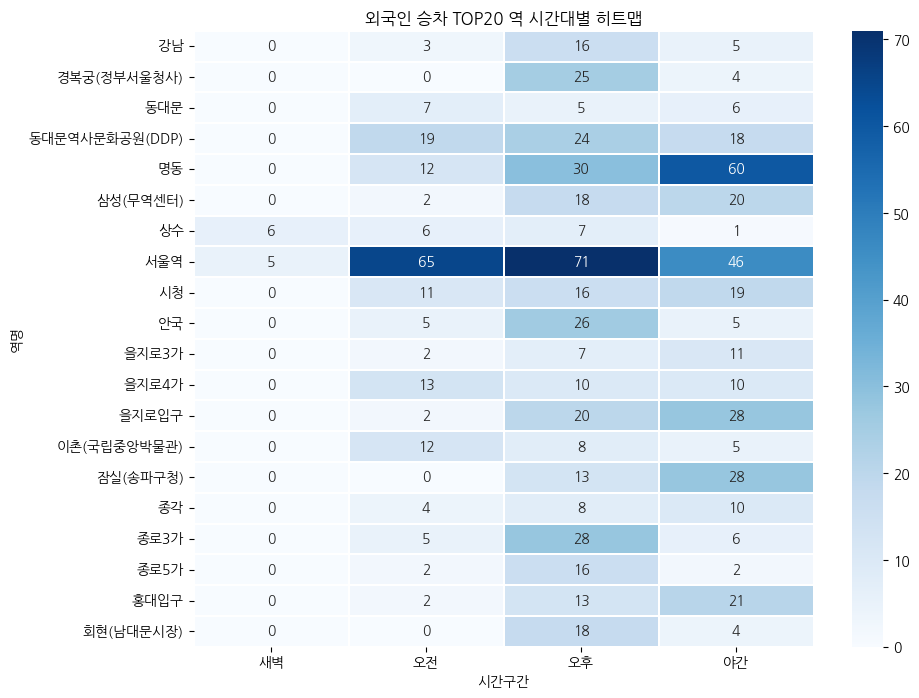

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 불러오기
df = pd.read_csv('C:\\Users\\USER\\OneDrive\\바탕 화면\\시각화 공모전 데이터\\서울교통공사_외국인 관광객 기간권 일별통행통계.csv', encoding='cp949')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'

# 시간대 그룹 함수
def time_group(hour):
    if 0 <= hour <= 5:
        return '새벽'
    elif 6 <= hour <= 11:
        return '오전'
    elif 12 <= hour <= 17:
        return '오후'
    else:
        return '야간'

# 시간구간 컬럼 생성
df['시간구간'] = df['시간대'].apply(time_group)

# =========================
# 역별 시간대별 승차건수 집계
# =========================

station_time_boarding = df.groupby(
    ['역명', '시간구간']
)['승차건수'].sum().reset_index()

print(station_time_boarding.head())

# =========================
# Pivot Table 생성
# =========================

pivot_boarding = station_time_boarding.pivot(
    index='역명',
    columns='시간구간',
    values='승차건수'
).fillna(0)

# 시간 순서 고정
pivot_boarding = pivot_boarding[
    ['새벽', '오전', '오후', '야간']
]

print(pivot_boarding.head())

# =========================
# 외국인 승차 TOP20 역 추출
# =========================

top20_boarding = df.groupby('역명')['승차건수'] \
                   .sum() \
                   .sort_values(ascending=False) \
                   .head(20)

# TOP20 역만 필터링
top20_boarding_df = df[
    df['역명'].isin(top20_boarding.index)
]

# 다시 집계
station_time_boarding_top20 = top20_boarding_df.groupby(
    ['역명', '시간구간']
)['승차건수'].sum().reset_index()

# Pivot 생성
pivot_boarding_top20 = station_time_boarding_top20.pivot(
    index='역명',
    columns='시간구간',
    values='승차건수'
).fillna(0)

# 시간 순서 고정
pivot_boarding_top20 = pivot_boarding_top20[
    ['새벽', '오전', '오후', '야간']
]

# =========================
# 히트맵 시각화
# =========================

plt.figure(figsize=(10,8))

sns.heatmap(
    pivot_boarding_top20,
    cmap='Blues',
    annot=True,
    fmt='.0f',
    linewidths=0.3
)

plt.title('외국인 승차 TOP20 역 시간대별 히트맵')
plt.xlabel('시간구간')
plt.ylabel('역명')

plt.show()

     역명 시간구간  승차건수
0    강남   야간     5
1    강남   오전     3
2    강남   오후    16
3  강남구청   오전     0
4  강남구청   오후     0
시간구간          새벽   오전    오후   야간
역명                              
강남           0.0  3.0  16.0  5.0
강남구청         0.0  0.0   0.0  0.0
강변(동서울터미널)   0.0  0.0   1.0  0.0
건대입구         0.0  0.0   1.0  4.0
경복궁(정부서울청사)  0.0  0.0  25.0  4.0


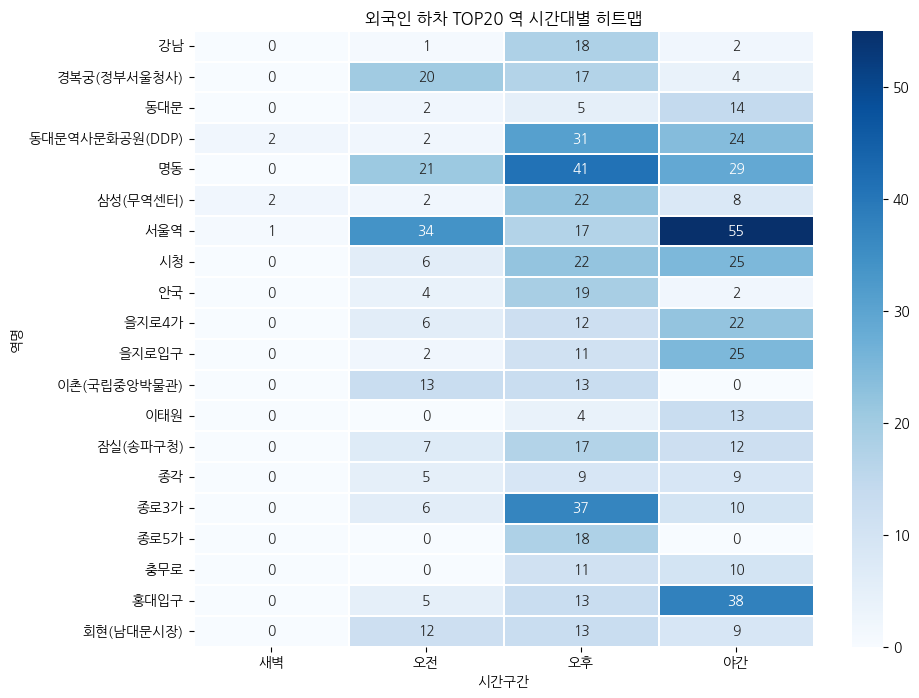

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 불러오기
df = pd.read_csv('C:\\Users\\USER\\OneDrive\\바탕 화면\\시각화 공모전 데이터\\서울교통공사_외국인 관광객 기간권 일별통행통계.csv', encoding='cp949')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'

# 시간대 그룹 함수
def time_group(hour):
    if 0 <= hour <= 5:
        return '새벽'
    elif 6 <= hour <= 11:
        return '오전'
    elif 12 <= hour <= 17:
        return '오후'
    else:
        return '야간'

# 시간구간 컬럼 생성
df['시간구간'] = df['시간대'].apply(time_group)

# =========================
# 역별 시간대별 승차건수 집계
# =========================

station_time_boarding = df.groupby(
    ['역명', '시간구간']
)['승차건수'].sum().reset_index()

print(station_time_boarding.head())

# =========================
# Pivot Table 생성
# =========================

pivot_boarding = station_time_boarding.pivot(
    index='역명',
    columns='시간구간',
    values='승차건수'
).fillna(0)

# 시간 순서 고정
pivot_boarding = pivot_boarding[
    ['새벽', '오전', '오후', '야간']
]

print(pivot_boarding.head())

# =========================
# 외국인 승차 TOP20 역 추출
# =========================

top20_boarding = df.groupby('역명')['하차건수'] \
                   .sum() \
                   .sort_values(ascending=False) \
                   .head(20)

# TOP20 역만 필터링
top20_boarding_df = df[
    df['역명'].isin(top20_boarding.index)
]

# 다시 집계
station_time_boarding_top20 = top20_boarding_df.groupby(
    ['역명', '시간구간']
)['하차건수'].sum().reset_index()

# Pivot 생성
pivot_boarding_top20 = station_time_boarding_top20.pivot(
    index='역명',
    columns='시간구간',
    values='하차건수'
).fillna(0)

# 시간 순서 고정
pivot_boarding_top20 = pivot_boarding_top20[
    ['새벽', '오전', '오후', '야간']
]

# =========================
# 히트맵 시각화
# =========================

plt.figure(figsize=(10,8))

sns.heatmap(
    pivot_boarding_top20,
    cmap='Blues',
    annot=True,
    fmt='.0f',
    linewidths=0.3
)

plt.title('외국인 하차 TOP20 역 시간대별 히트맵')
plt.xlabel('시간구간')
plt.ylabel('역명')

plt.show()

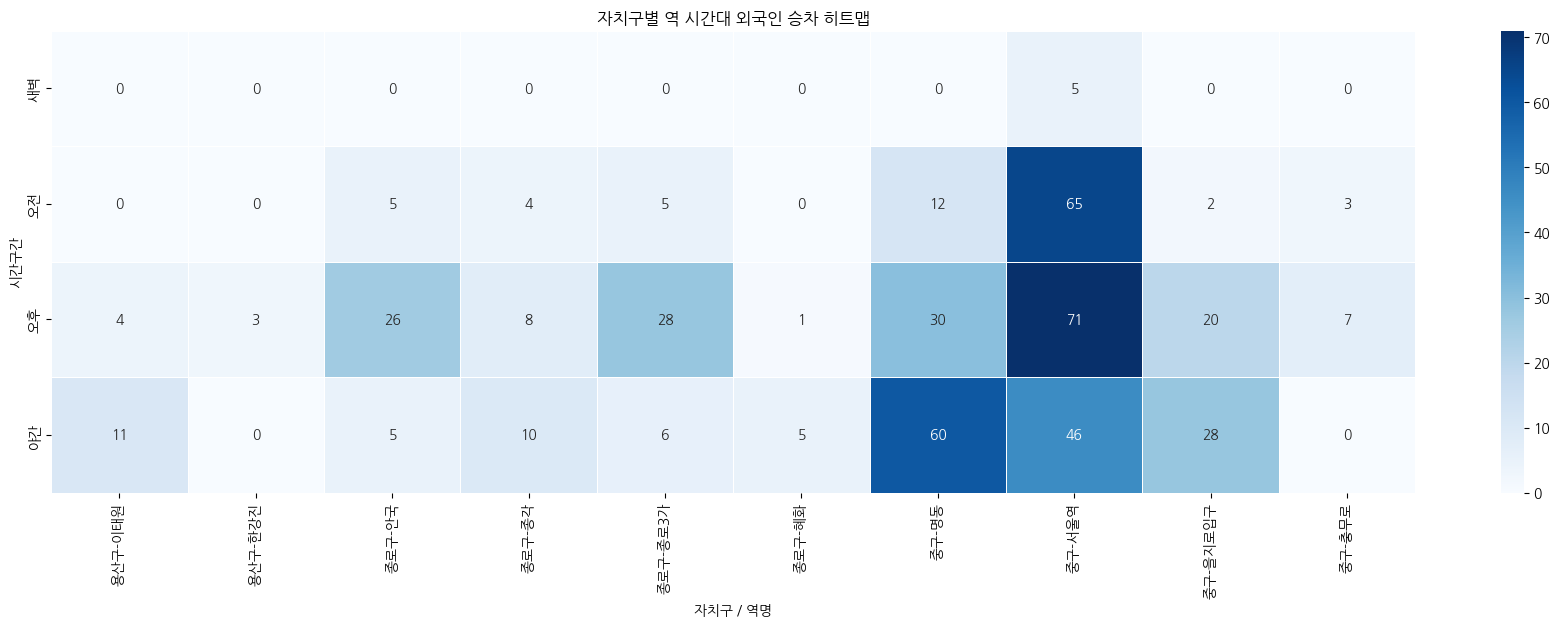

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 데이터 불러오기
# =========================

df = pd.read_csv(r'C:\\Users\\USER\\OneDrive\\바탕 화면\\시각화 공모전 데이터\\서울교통공사_외국인 관광객 기간권 일별통행통계.csv', encoding='cp949')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'

def time_group(hour):
    if 0 <= hour <= 5:
        return '새벽'
    elif 6 <= hour <= 11:
        return '오전'
    elif 12 <= hour <= 17:
        return '오후'
    else:
        return '야간'

df['시간구간'] = df['시간대'].apply(time_group)

# =========================
# 자치구별 역 리스트
# =========================

district_stations = {

    '강동구': [
        '천호', '강동', '길동', '둔촌동',
        '상일동', '고덕', '명일'
    ],

    '관악구': [
        '서울대입구', '신림', '봉천',
        '낙성대'
    ],

    '노원구': [
        '노원', '상계', '중계',
        '하계', '공릉', '태릉입구'
    ],

    '용산구': [
        '서울역', '용산', '이촌',
        '이태원', '한강진', '삼각지'
    ],

    '종로구': [
        '종각', '종로3가', '광화문',
        '경복궁', '안국', '혜화'
    ],

    '중구': [
        '명동', '을지로입구',
        '동대문역사문화공원',
        '충무로', '서울역'
    ]
}

# =========================
# 역명 -> 자치구 매핑
# =========================

station_to_district = {}

for district, stations in district_stations.items():
    for station in stations:
        station_to_district[station] = district

# 자치구 컬럼 추가
df['자치구'] = df['역명'].map(station_to_district)

# 필요한 역만 필터링
filtered_df = df[df['자치구'].notna()]

# =========================
# 역별 시간대별 승차건수 집계
# =========================

station_time = filtered_df.groupby(
    ['자치구', '역명', '시간구간']
)['승차건수'].sum().reset_index()

# =========================
# Pivot Table 생성
# =========================

pivot = station_time.pivot_table(
    index='시간구간',
    columns=['자치구', '역명'],
    values='승차건수',
    aggfunc='sum'
).fillna(0)

# 시간 순서 고정
pivot = pivot.reindex(
    ['새벽', '오전', '오후', '야간']
)

# =========================
# 히트맵 시각화
# =========================

plt.figure(figsize=(22, 6))

sns.heatmap(
    pivot,
    cmap='Blues',
    annot=True,
    fmt='.0f',
    linewidths=0.5
)

plt.title('자치구별 역 시간대 외국인 승차 히트맵')
plt.xlabel('자치구 / 역명')
plt.ylabel('시간구간')

plt.xticks(rotation=90)

plt.show()